In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import decomposition
in_dir = "data/"
txt_name = "irisdata.txt"

**Ex 1**: read and analyse data

In [3]:
# Fetch data

iris_data = np.loadtxt(in_dir + txt_name, comments="%")
x = iris_data[0:50, 0:4] # x is a matrix with 50 rows and 4 columns

# Check data dimensions:
n_feat = x.shape[1]
n_obs = x.shape[0]
print(f"Number of features: {n_feat} and number of observations: {n_obs}")
print(f"Shape: {x.shape}")

Number of features: 4 and number of observations: 50
Shape: (50, 4)


**Ex 2**: Data exploration

In [4]:
# Separate variables
sep_l = x[:, 0]
sep_w = x[:, 1]
pet_l = x[:, 2]
pet_w = x[:, 3]

# compute variances of features
var_sep_l = sep_l.var(ddof=1)
var_sep_w = sep_w.var(ddof=1)
var_pet_l = pet_l.var(ddof=1)
var_pet_w = pet_w.var(ddof=1)
print(f"Variances: {var_sep_l}, {var_sep_w}, {var_pet_l}, {var_pet_w}") # Larger variances for sepal features

Variances: 0.12424897959183677, 0.1436897959183674, 0.030159183673469384, 0.01110612244897959


**Ex 3**: Compute covariances of features

In [5]:
C = np.zeros((4,4))
for i, feat in enumerate(x.T):
    for j, comp_feat in enumerate(x.T):
        C[i, j] = (1/(n_obs-1)) * (feat * comp_feat).sum()

**Ex 4**: Employ pairplot. What measures are related and which are not?

<Figure size 640x480 with 0 Axes>

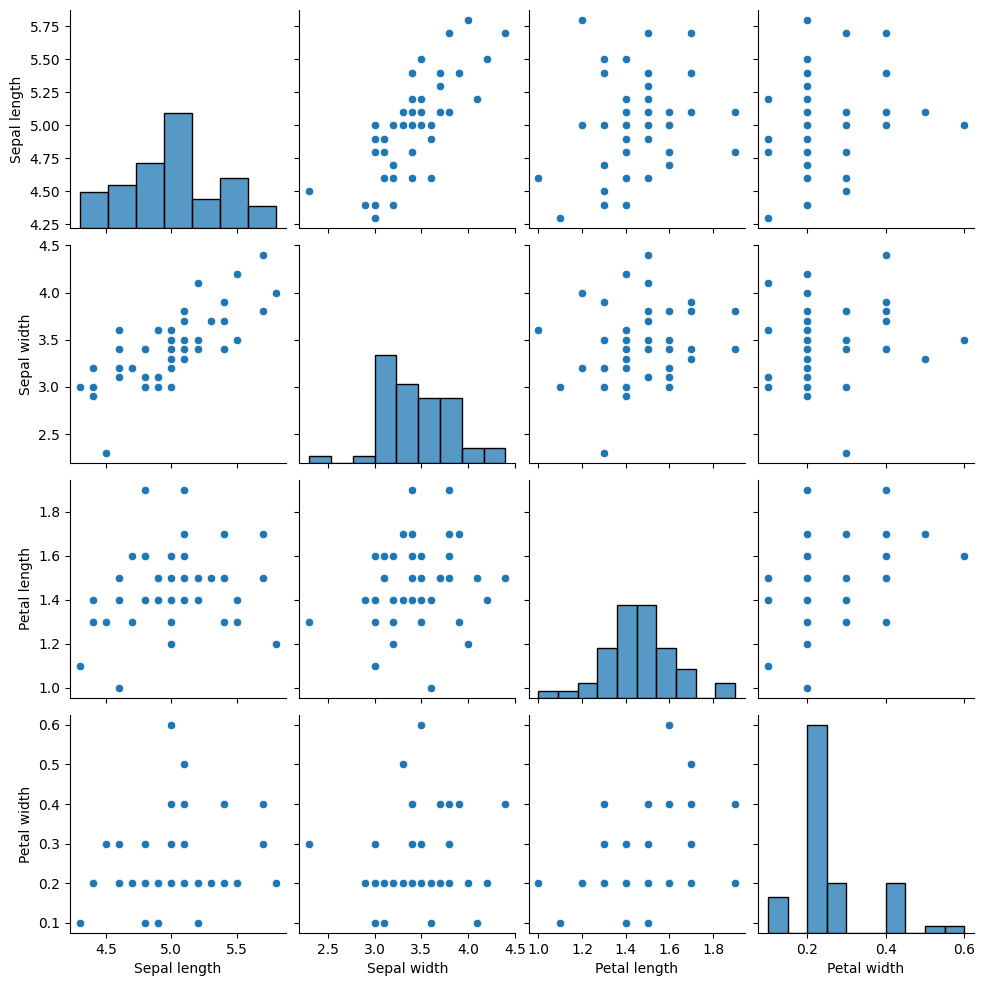

In [6]:
plt.figure() # Added this to make sure that the figure appear
# Transform the data into a Pandas dataframe
d = pd.DataFrame(x, columns=['Sepal length', 'Sepal width',
							 'Petal length', 'Petal width'])
sns.pairplot(d)
plt.show()

Diagonal is feature variance, whilst off-diagonal is covariance between variables (symmetric). High covariance means high relation, which can be measured through features' linear relationship. High correlation can be found for the sepal length vs sepal width.

#### PCA Analysis

**Ex 5, 6, 7 and 8**: Perform manual PCA analysis

In [9]:
C_x.shape

(4, 4)

In [8]:
# Subtract mean from data:
m = np.mean(x, axis=0)
data = x - m

# Compute covariance (mean subtracted, hence this is the cov)
C_x = (1/(n_obs-1)) * data.T @ data

# Compute PCs using eigenvector analysis
values, vectors = np.linalg.eig(C_x)

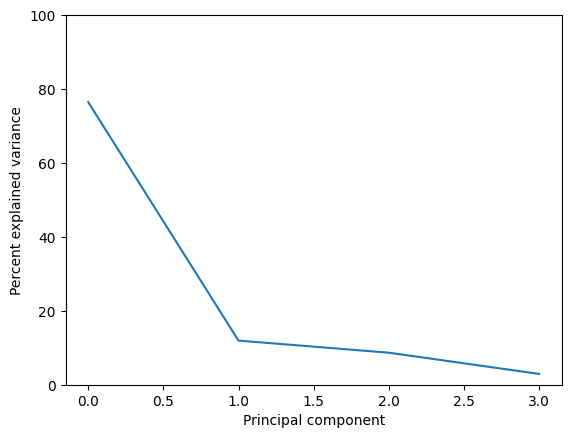

In [10]:
# Examine properties of the PCs
v_norm = values / values.sum() * 100
plt.plot(v_norm)
plt.xlabel('Principal component')
plt.ylabel('Percent explained variance')
plt.ylim([0, 100])

plt.show()

First component explains ~75% of the variance, with 2 already approaching 100%

<Figure size 640x480 with 0 Axes>

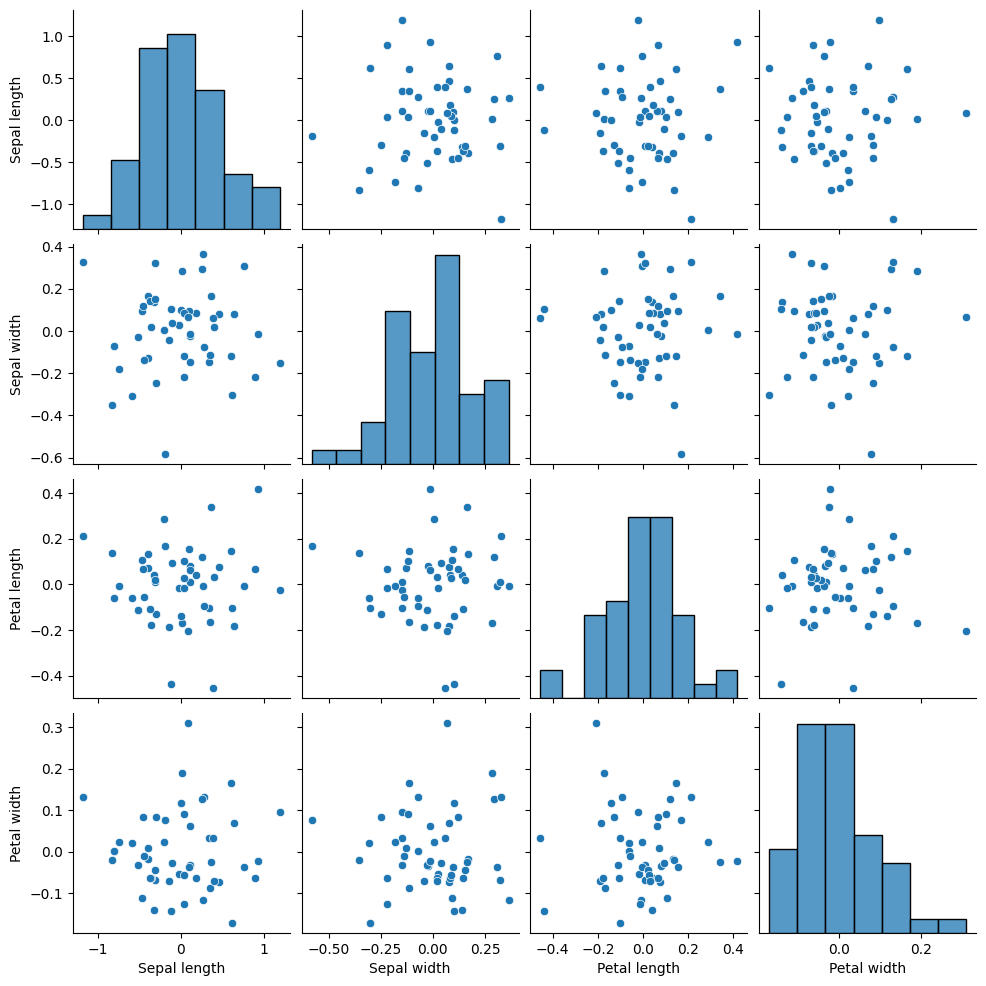

In [13]:
# Project data onto PCA space:
# pc_proj = data @ vectors
pc_proj = vectors.T.dot(data.T).T

# Produce pairplot over new data
C_pc_proj = (1/(n_obs-1)) * np.matmul(pc_proj, pc_proj.T)

plt.figure() # Added this to make sure that the figure appear
# Transform the data into a Pandas dataframe
d = pd.DataFrame(pc_proj, columns=['Sepal length', 'Sepal width',
							 'Petal length', 'Petal width'])
sns.pairplot(d)
plt.show()

~0 covariance between features.

**Ex 9**: Employ sklearn.decomposition to automate PCA

<Figure size 640x480 with 0 Axes>

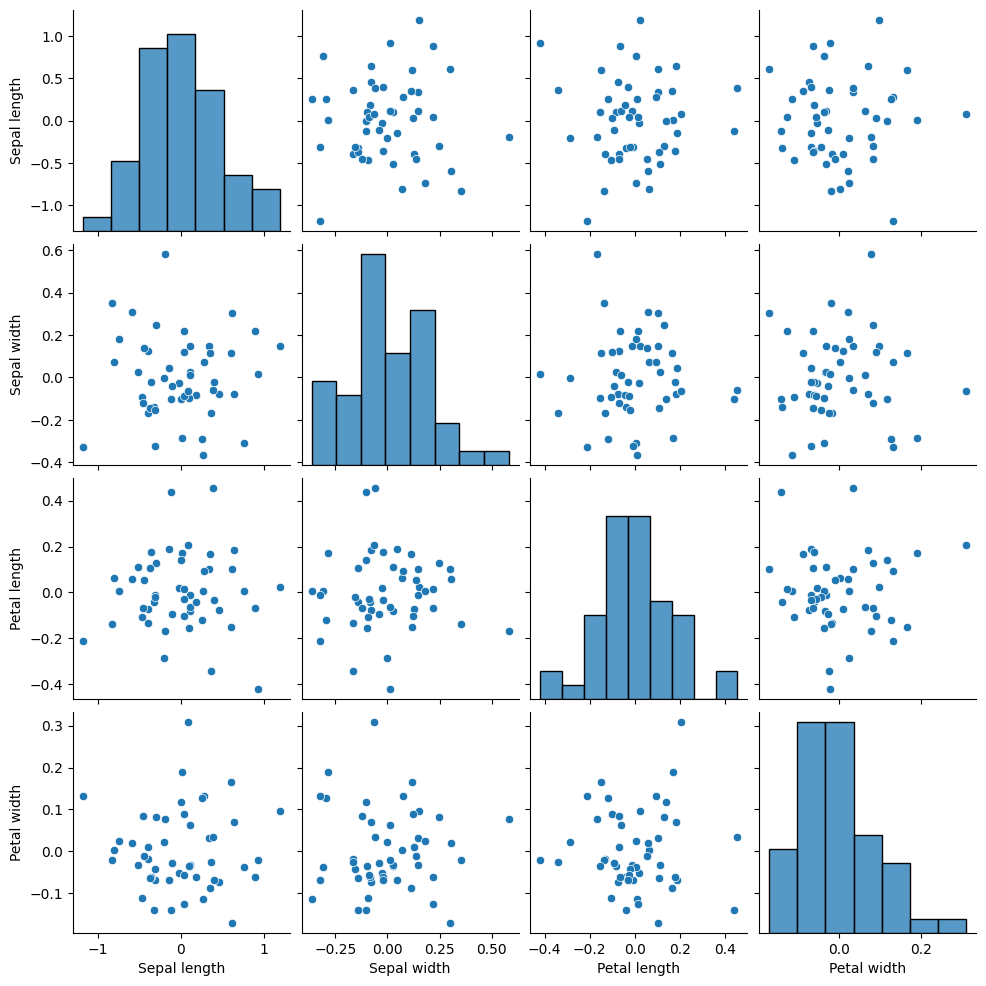

In [ ]:
pca = decomposition.PCA() 
pca.fit(x) # Subtracts mean for us
values_pca = pca.explained_variance_
exp_var_ratio = pca.explained_variance_ratio_
vectors_pca = pca.components_

data_transform = pca.transform(x)

# Compare pairplot
plt.figure() # Added this to make sure that the figure appear
# Transform the data into a Pandas dataframe
d = pd.DataFrame(data_transform, columns=['Sepal length', 'Sepal width',
							 'Petal length', 'Petal width'])
sns.pairplot(d)
plt.show()